In [1]:
import s3fs
import xarray as xr
import numpy as np
import pandas as pd
import boto3
import gsw
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import matplotlib.patches as mpatches
import cmocean
import subprocess

### convert data product climatologies to 1dbar z-axes

In [17]:
def interp_data_product_pres(filename,varname):

    # filename= 'RG09_potential_temperature_2004-2024_monthly_climatology.nc'
    # varname='temp'
    
    s3_path = 's3://uw-escience-scratch-prod/team_mhw/'
    
    #open file and interpolate to 1dbar pressure bins
    ds_GOBAI = xr.open_dataset(s3_path+filename, engine="h5netcdf")[varname].sel(pres = slice(2.5,1000))
    new_pres = np.arange(0,1001,1)
    var_new_z = ds_GOBAI.interp(pres = new_pres,method = "linear", kwargs = {"fill_value":"extrapolate"})
    var_new_z.to_netcdf(path='/tmp/'+filename[:-3]+'_interpolated_pres_0-1000dbar.nc', mode = 'w')
    # move tmp file to the AWS bucket
    subprocess.run(f"aws s3 cp /tmp/{filename[:-3]}_interpolated_pres_0-1000dbar.nc s3://uw-escience-scratch-prod/team_mhw/", shell=True)
    

In [20]:
interp_data_product_pres(filename= 'RG09_potential_temperature_2004-2024_monthly_climatology.nc', varname = 'temp')
interp_data_product_pres(filename= 'RG09_absolute_salinity_2004-2024_monthly_climatology.nc', varname = 'sal')
interp_data_product_pres(filename= 'GOBAI-O2-v2.3_oxygen_2004-2024_monthly_climatology.nc', varname = 'oxy')
interp_data_product_pres(filename= 'GOBAI-O2-v2.3_AOU_2004-2024_monthly_climatology.nc', varname = 'AOU')
interp_data_product_pres(filename= 'GOBAI-O2-v2.3_oxysat_2004-2024_monthly_climatology.nc', varname = 'oxysat')

upload: ../../../../../tmp/GOBAI-O2-v2.3_AOU_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc to s3://uw-escience-scratch-prod/team_mhw/GOBAI-O2-v2.3_AOU_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc


upload: ../../../../../tmp/GOBAI-O2-v2.3_oxysat_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc to s3://uw-escience-scratch-prod/team_mhw/GOBAI-O2-v2.3_oxysat_2004-2024_monthly_climatology_interpolated_pres_0-1000dbar.nc


In [4]:
new_pres = np.arange(0,1001,1)
# new = xr.DataArray(newz_range,dims = ['pres'])

In [5]:
var_new_z = ds_GOBAI.interp(pres = new_pres,method = "linear", kwargs = {"fill_value":"extrapolate"})


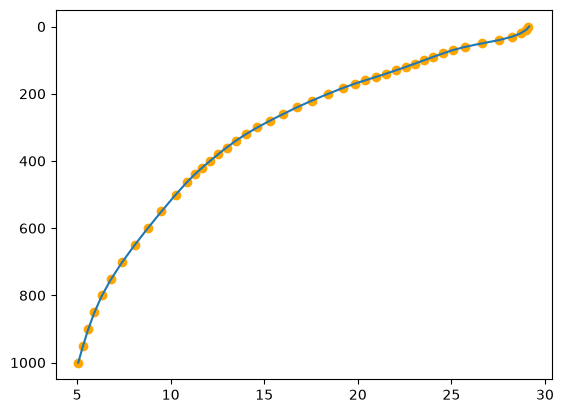

In [13]:
# example profile
plt.plot(var_new_z[1,:,50,50],var_new_z['pres'].values)

plt.scatter(ds_GOBAI[1,:,50,50],ds_GOBAI['pres'].values,color='orange')
plt.gca().invert_yaxis()

In [4]:
s3_path = "s3://uw-escience-scratch-prod/team_mhw/regridded_floats/"
#open GOBAI
ds_floats = xr.open_zarr(s3_path+'swp_regridded_profiles_full.zarr')


In [5]:
ds_floats

<xarray.Dataset> Size: 56MB
Dimensions:          (profile: 994, pres: 1001)
Coordinates:
    CYCLE_NUMBER     (profile) int64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    JULD             (profile) datetime64[ns] 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    LATITUDE         (profile) float64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    LONGITUDE        (profile) float64 8kB dask.array<chunksize=(994,), meta=np.ndarray>
    PLATFORM_NUMBER  (profile) <U7 28kB dask.array<chunksize=(994,), meta=np.ndarray>
  * pres             (pres) int64 8kB 0 1 2 3 4 5 6 ... 995 996 997 998 999 1000
  * profile          (profile) int64 8kB 0 1 2 3 4 5 ... 988 989 990 991 992 993
Data variables:
    ABS_SAL          (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    AOU              (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    CHLA             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    DOXY             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    O2_SATURATION    (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    POTENTIAL_TEMP   (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
    TEMP             (profile, pres) float64 8MB dask.array<chunksize=(249, 251), meta=np.ndarray>
Attributes:
    depth_units:  decibar
    max_depth:    1000
    region:       swp